<a href="https://colab.research.google.com/github/AISHWARYAARULSELVAN/IPCV/blob/main/Ex_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving ep_5.png to ep_5 (1).png
Image: ep_5 (1).png
Skin Pixels: 23547
Skin Percentage: 41.07%


/tmp/ipykernel_15075/2517257632.py:13: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(filename)


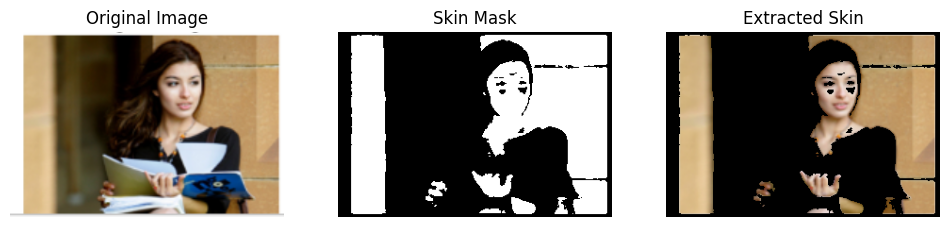

In [2]:
from google.colab import files
uploaded = files.upload()

import numpy as np
import matplotlib.pyplot as plt
from imageio import imread

%matplotlib inline

# Read uploaded image
filename = list(uploaded.keys())[0]

image = imread(filename)

# Convert image to RGB if needed
if image.shape[-1] == 4:
    image = image[:, :, :3]

# Simple skin detection using RGB thresholds
R = image[:, :, 0]
G = image[:, :, 1]
B = image[:, :, 2]

skin_pixels = (
    (R > 95) &
    (G > 40) &
    (B > 20) &
    ((np.maximum.reduce([R,G,B]) -
      np.minimum.reduce([R,G,B])) > 15) &
    (np.abs(R - G) > 15) &
    (R > G) &
    (R > B)
)

# Create skin image
skin_image = np.zeros_like(image)
skin_image[skin_pixels] = image[skin_pixels]

# Skin statistics
total_pixels = skin_pixels.size
skin_count = np.sum(skin_pixels)

skin_percentage = (skin_count / total_pixels) * 100

print("Image:", filename)
print("Skin Pixels:", skin_count)
print("Skin Percentage: %.2f%%" % skin_percentage)

# Display Results
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(skin_pixels, cmap='gray')
plt.title("Skin Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(skin_image)
plt.title("Extracted Skin")
plt.axis("off")

plt.show()